# Indonesian Food Price Forecastibility
## Project Summary

This project investigates the forecastability of major Indonesian food commodities using daily price data from the National Strategic Food Price Information Center (PIHPS) from 2021–2025. Commodity-specific characteristics, including volatility, autocorrelation, and trend, are extracted and analyzed to understand their relationship with forecasting performance. Forecast accuracy is evaluated using both a classical statistical model (ARIMA) and a machine learning model (XGBoost). The objective is to determine whether certain commodities are inherently more difficult to forecast and to identify the factors associated with forecasting difficulty.

## Data Loading

In [28]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress
from statsmodels.tsa.stattools import acf
from statsmodels.tsa.arima.model import ARIMA

from xgboost import XGBRegressor

from sklearn.metrics import mean_squared_error

import warnings
warnings.filterwarnings("ignore")

In [29]:
df = pd.read_csv(
    "data/food_prices_2021_2025_clean.csv"
)

df["Date"] = pd.to_datetime(
    df["Date"]
)

df = df.sort_values(
    "Date"
)

df.head()

,Date,Rice,Chicken,Beef,Eggs,Shallots,Garlic,Red Chili,Bird's Eye Chili,Cooking Oil,Sugar
0,2021-01-01,-,-,-,-,-,-,-,-,-,-
1,2021-01-04,"11,800","36,050","118,750","27,700","33,950","28,550","57,500","68,900","14,450","14,400"
2,2021-01-05,"11,800","36,000","119,300","27,600","33,850","28,500","57,350","68,500","14,500","14,450"
3,2021-01-06,"11,800","36,100","119,400","27,650","33,700","28,450","56,350","68,850","14,500","14,400"
4,2021-01-07,"11,800","36,150","119,400","27,600","33,550","28,500","55,900","69,550","14,500","14,400"


In [30]:
df["Date"] = pd.to_datetime(df["Date"])

for col in df.columns[1:]:

    df[col] = (
        df[col]
        .astype(str)
        .str.replace(",", "", regex=False)
    )

    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )

df = df.ffill().bfill()

In [48]:
len(df)

1304

In [31]:
print(df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isna().sum())

(1304, 11)

Data Types:
Date                datetime64[ns]
Rice                       float64
Chicken                    float64
Beef                       float64
Eggs                       float64
Shallots                   float64
Garlic                     float64
Red Chili                  float64
Bird's Eye Chili           float64
Cooking Oil                float64
Sugar                      float64
dtype: object

Missing Values:
Date                0
Rice                0
Chicken             0
Beef                0
Eggs                0
Shallots            0
Garlic              0
Red Chili           0
Bird's Eye Chili    0
Cooking Oil         0
Sugar               0
dtype: int64


## Exploratory Data Analysis

### Summary Statistics

In [32]:
summary = (
    df
    .drop("Date", axis=1)
    .describe()
    .T
)

summary["CV"] = (
    summary["std"]
    /
    summary["mean"]
)

summary = summary.sort_values(
    "CV",
    ascending=False
)

summary

,count,mean,std,min,25%,50%,75%,max,CV
Red Chili,1304.0,49393.251534,11055.084488,17500.0,41750.0,48600.0,55700.0,89050.0,0.223818
Bird's Eye Chili,1304.0,55922.622699,12153.152654,22000.0,46387.5,53875.0,64150.0,91750.0,0.217321
Shallots,1304.0,38561.694785,7599.631113,26000.0,32850.0,37425.0,42150.0,64800.0,0.197077
Garlic,1304.0,36474.846626,6353.743282,24000.0,29950.0,38325.0,42100.0,48100.0,0.174195
Rice,1304.0,13678.182515,1656.259040,11000.0,11800.0,13550.0,15300.0,16000.0,0.121088
Sugar,1304.0,16473.159509,1942.193296,13400.0,15050.0,15400.0,18600.0,19300.0,0.117900
Cooking Oil,1304.0,19258.895706,2196.245280,14400.0,18800.0,19300.0,20700.0,25700.0,0.114038
Eggs,1304.0,29034.969325,2478.488479,18250.0,27650.0,29575.0,30600.0,43000.0,0.085362
Chicken,1304.0,36557.170245,2065.684706,29000.0,35250.0,36250.0,37650.0,52100.0,0.056506
Beef,1304.0,132432.630368,5652.403171,100650.0,130600.0,134675.0,135500.0,157500.0,0.042681


### Volatility

In [33]:
summary["CV"] = (
    summary["std"] /
    summary["mean"]
)

summary = summary.sort_values(
    "CV",
    ascending=False
)

summary[[
    "mean",
    "std",
    "CV"
]]

,mean,std,CV
Red Chili,49393.251534,11055.084488,0.223818
Bird's Eye Chili,55922.622699,12153.152654,0.217321
Shallots,38561.694785,7599.631113,0.197077
Garlic,36474.846626,6353.743282,0.174195
Rice,13678.182515,1656.259040,0.121088
Sugar,16473.159509,1942.193296,0.117900
Cooking Oil,19258.895706,2196.245280,0.114038
Eggs,29034.969325,2478.488479,0.085362
Chicken,36557.170245,2065.684706,0.056506
Beef,132432.630368,5652.403171,0.042681


### Commodity Price Trends

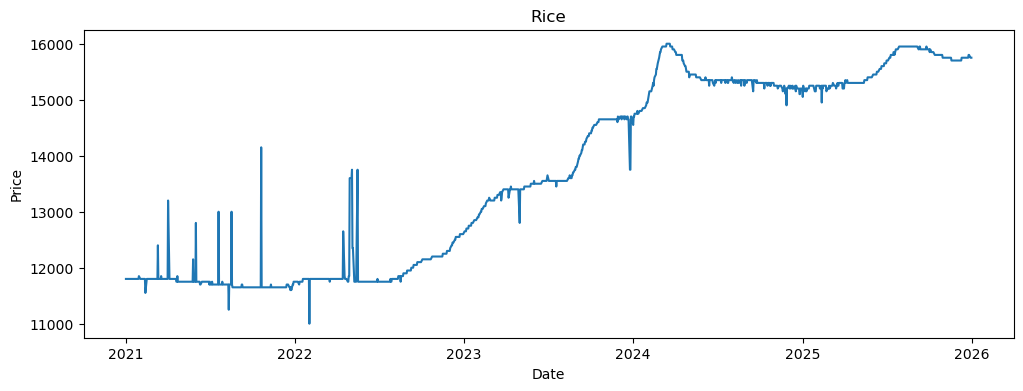

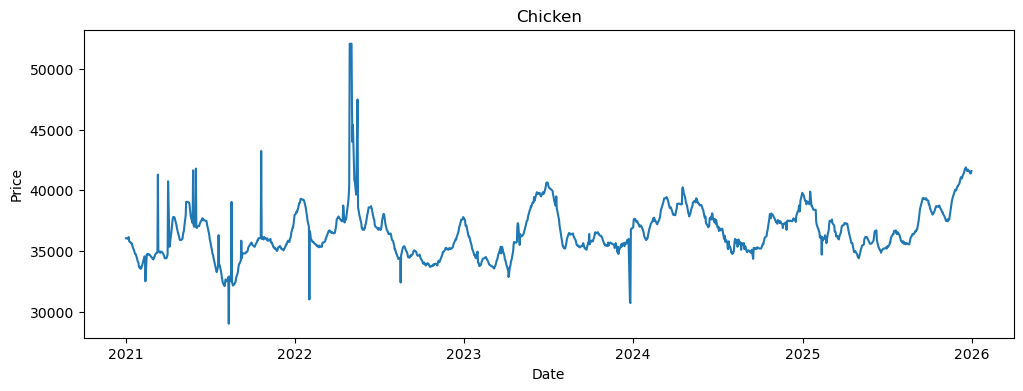

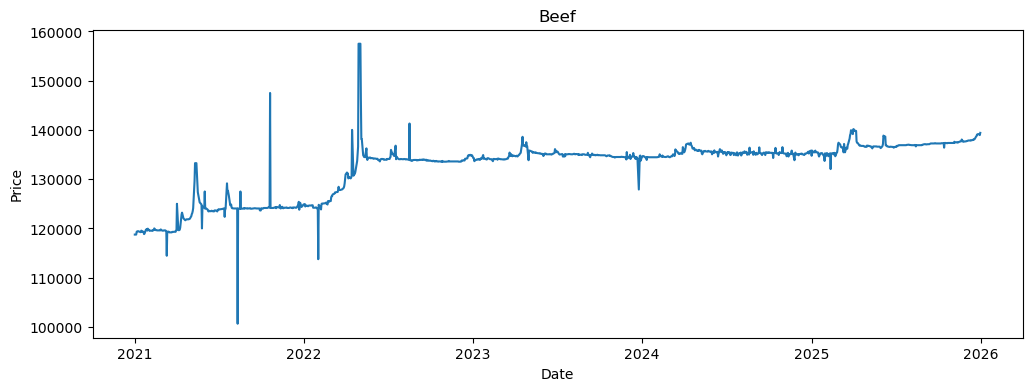

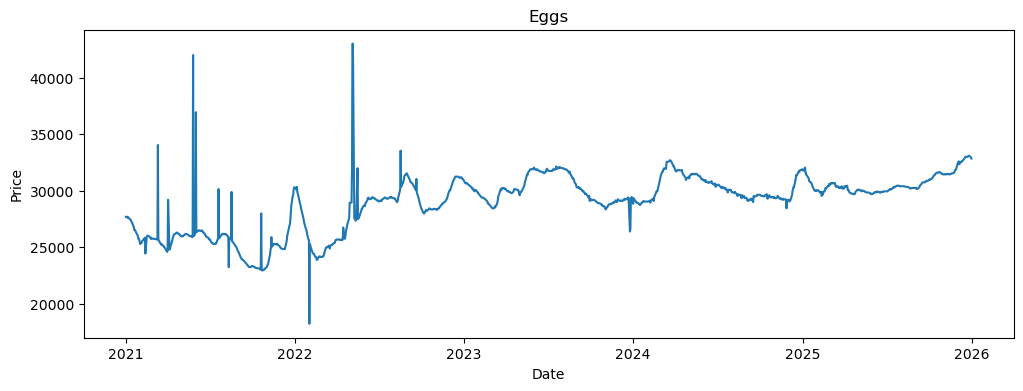

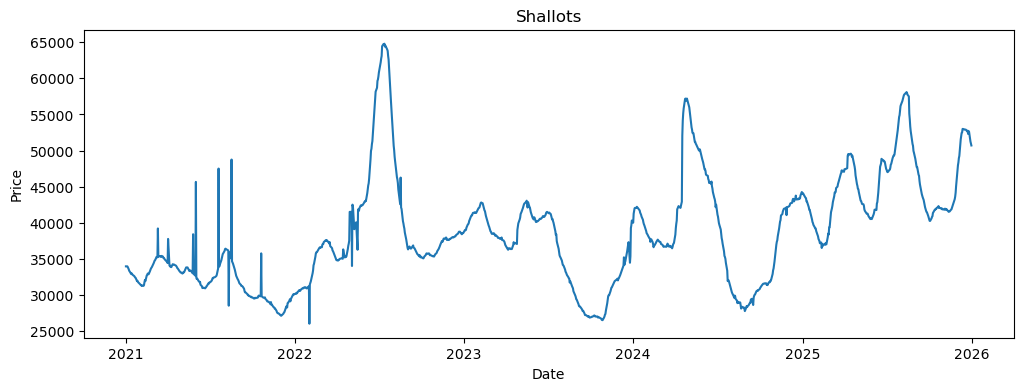

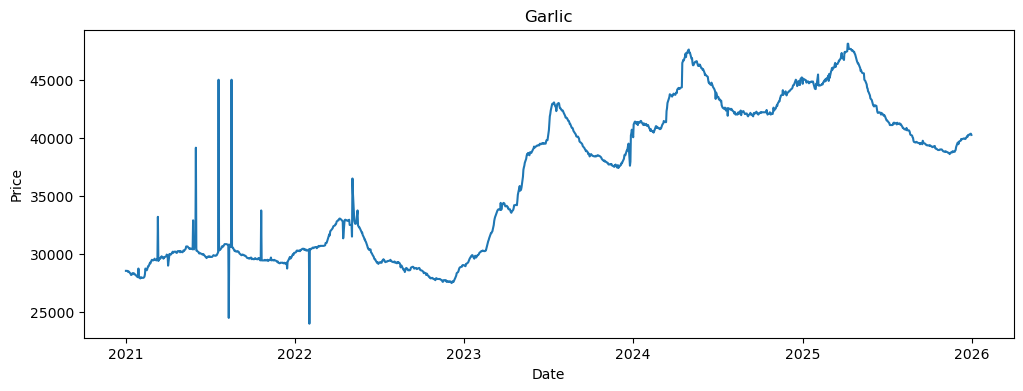

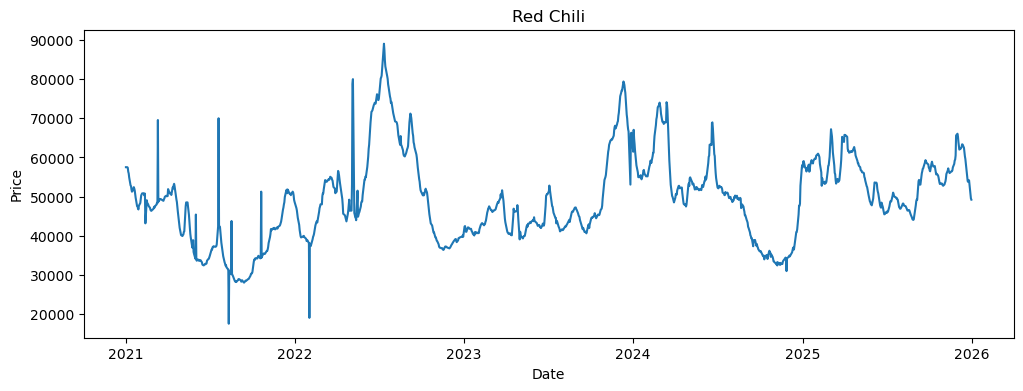

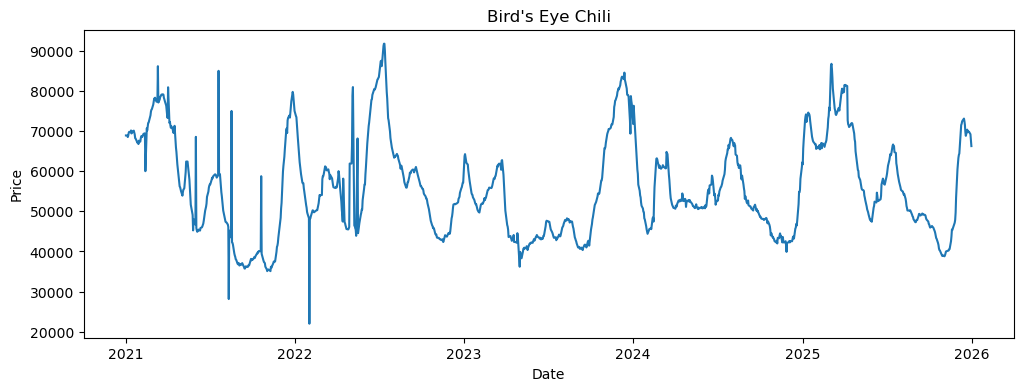

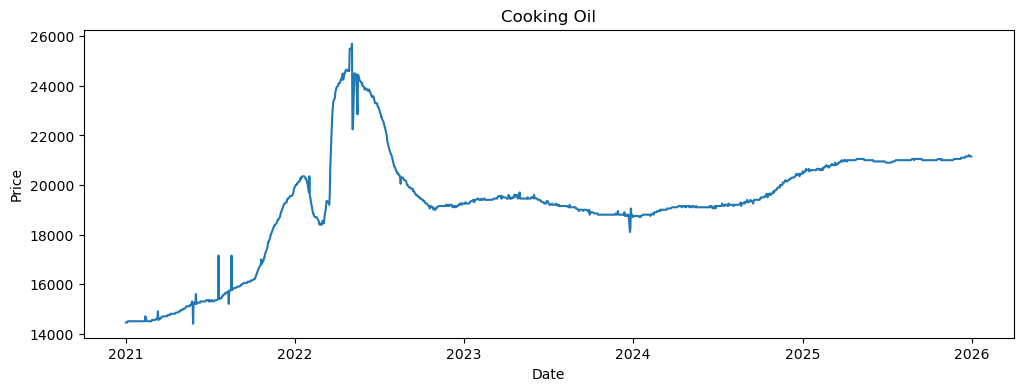

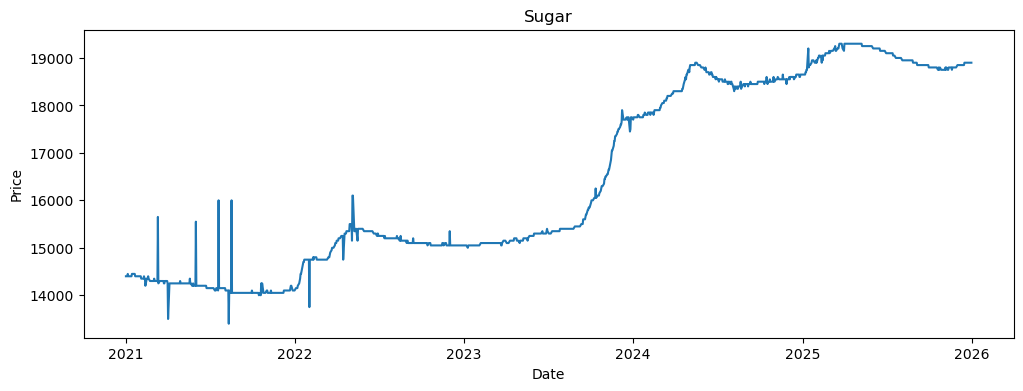

In [34]:
for commodity in df.columns[1:]:

    plt.figure(figsize=(12,4))

    plt.plot(
        df["Date"],
        df[commodity]
    )

    plt.title(
        commodity
    )

    plt.xlabel("Date")

    plt.ylabel("Price")

    plt.show()

### Correlation Heatmap

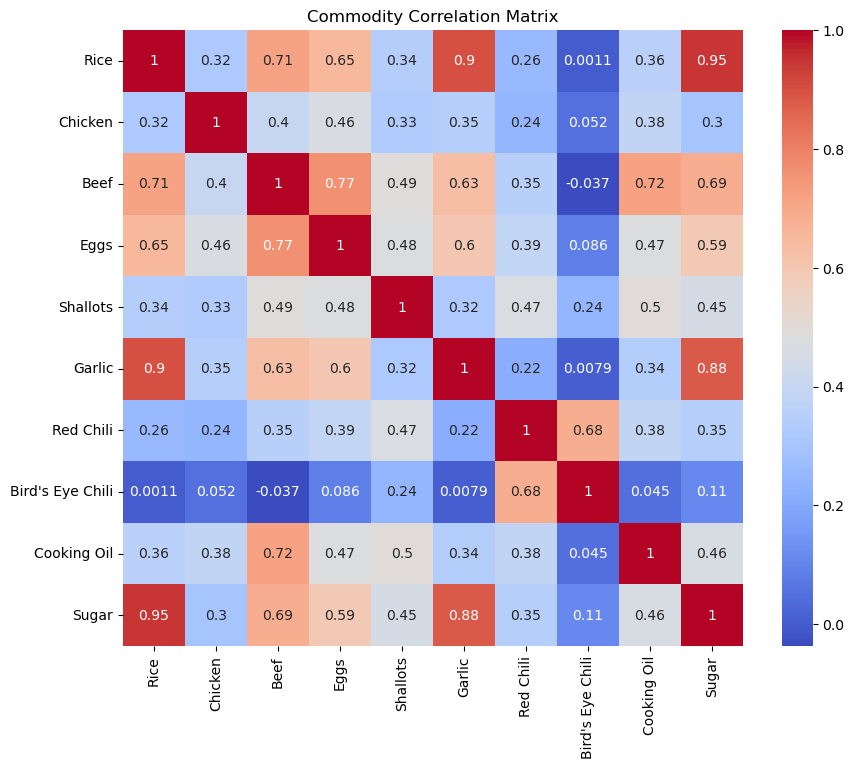

In [35]:
corr = (
    df
    .drop("Date", axis=1)
    .corr()
)

plt.figure(
    figsize=(10,8)
)

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title(
    "Commodity Correlation Matrix"
)

plt.show()

## Forecastability Feature Extraction

In [36]:
features = []

for commodity in df.columns[1:]:

    series = pd.to_numeric(
        df[commodity],
        errors="coerce"
    ).dropna()

    mean_price = series.mean()

    sd_price = series.std()

    cv = sd_price / mean_price

    acf1 = acf(series, nlags=1)[1]

    trend = linregress(
        np.arange(len(series)),
        series
    ).slope

    features.append([
        commodity,
        mean_price,
        sd_price,
        cv,
        acf1,
        trend
    ])

feature_df = pd.DataFrame(
    features,
    columns=[
        "Commodity",
        "Mean",
        "SD",
        "CV",
        "ACF1",
        "Trend"
    ]
)

feature_df

,Commodity,Mean,SD,CV,ACF1,Trend
0,Rice,13678.182515,1656.259040,0.121088,0.992322,4.149494
1,Chicken,36557.170245,2065.684706,0.056506,0.904303,1.560538
2,Beef,132432.630368,5652.403171,0.042681,0.950326,11.930525
3,Eggs,29034.969325,2478.488479,0.085362,0.896266,4.484223
4,Shallots,38561.694785,7599.631113,0.197077,0.985232,8.902946
5,Garlic,36474.846626,6353.743282,0.174195,0.986695,14.140023
6,Red Chili,49393.251534,11055.084488,0.223818,0.971916,7.993588
7,Bird's Eye Chili,55922.622699,12153.152654,0.217321,0.965902,-1.047187
8,Cooking Oil,19258.895706,2196.245280,0.114038,0.994272,3.206230
9,Sugar,16473.159509,1942.193296,0.117900,0.995840,4.848105


## Forecasting Models

### Train/Test Split

In [37]:
train = df[
    df["Date"] < "2025-01-01"
]

test = df[
    df["Date"] >= "2025-01-01"
]

print(train.shape)
print(test.shape)

(1043, 11)
(261, 11)


### Lag Function

In [38]:
def make_lags(df, commodity):

    temp = pd.DataFrame()

    temp["Date"] = df["Date"]

    temp["y"] = df[commodity]

    temp["lag_1"] = (
        df[commodity]
        .shift(1)
    )

    temp["lag_7"] = (
        df[commodity]
        .shift(7)
    )

    temp["lag_14"] = (
        df[commodity]
        .shift(14)
    )

    temp["lag_30"] = (
        df[commodity]
        .shift(30)
    )

    temp = temp.dropna()

    return temp

### Forecasting

In [39]:
results = []

for commodity in df.columns[1:]:

    print(
        f"Running {commodity}"
    )

    series = pd.to_numeric(
        df[commodity],
        errors="coerce"
    ).dropna()

    mean_price = series.mean()

    sd_price = series.std()

    cv = (
        sd_price
        /
        mean_price
    )

    acf1 = acf(
        series,
        nlags=1
    )[1]

    trend = linregress(
        np.arange(len(series)),
        series
    ).slope

    # =====================
    # ARIMA
    # =====================

    train_series = (
        train[commodity]
    )

    test_series = (
        test[commodity]
    )

    arima_model = ARIMA(
        train_series,
        order=(1,1,1)
    )

    arima_fit = (
        arima_model.fit()
    )

    arima_forecast = (
        arima_fit.forecast(
            steps=len(
                test_series
            )
        )
    )

    arima_rmse = np.sqrt(
        mean_squared_error(
            test_series,
            arima_forecast
        )
    )

    # =====================
    # XGBOOST
    # =====================

    lag_df = make_lags(
        df,
        commodity
    )

    train_x = lag_df[
        lag_df["Date"]
        < "2025-01-01"
    ]

    test_x = lag_df[
        lag_df["Date"]
        >= "2025-01-01"
    ]

    X_train = train_x.drop(
        columns=[
            "Date",
            "y"
        ]
    )

    y_train = train_x["y"]

    X_test = test_x.drop(
        columns=[
            "Date",
            "y"
        ]
    )

    y_test = test_x["y"]

    xgb = XGBRegressor(

        n_estimators=300,

        max_depth=4,

        learning_rate=0.05,

        random_state=42

    )

    xgb.fit(
        X_train,
        y_train
    )

    pred = xgb.predict(
        X_test
    )

    xgb_rmse = np.sqrt(
        mean_squared_error(
            y_test,
            pred
        )
    )

    results.append({

        "Commodity":
            commodity,

        "Mean":
            mean_price,

        "SD":
            sd_price,

        "CV":
            cv,

        "ACF1":
            acf1,

        "Trend":
            trend,

        "ARIMA_RMSE":
            arima_rmse,

        "XGB_RMSE":
            xgb_rmse

    })

Running Rice
Running Chicken
Running Beef
Running Eggs
Running Shallots
Running Garlic
Running Red Chili
Running Bird's Eye Chili
Running Cooking Oil
Running Sugar


### Results Table

In [40]:
results = pd.DataFrame(
    results
)

results = results.sort_values(
    "CV",
    ascending=False
)

results

,Commodity,Mean,SD,CV,ACF1,Trend,ARIMA_RMSE,XGB_RMSE
6,Red Chili,49393.251534,11055.084488,0.223818,0.971916,7.993588,5907.958897,1593.261599
7,Bird's Eye Chili,55922.622699,12153.152654,0.217321,0.965902,-1.047187,12197.359606,1805.817679
4,Shallots,38561.694785,7599.631113,0.197077,0.985232,8.902946,5353.953401,704.540842
5,Garlic,36474.846626,6353.743282,0.174195,0.986695,14.140023,3856.793731,296.140311
0,Rice,13678.182515,1656.259040,0.121088,0.992322,4.149494,480.270282,41.471484
9,Sugar,16473.159509,1942.193296,0.117900,0.995840,4.848105,414.580622,305.507031
8,Cooking Oil,19258.895706,2196.245280,0.114038,0.994272,3.206230,512.751497,154.265005
3,Eggs,29034.969325,2478.488479,0.085362,0.896266,4.484223,1359.250279,182.003874
1,Chicken,36557.170245,2065.684706,0.056506,0.904303,1.560538,2918.535806,684.476250
2,Beef,132432.630368,5652.403171,0.042681,0.950326,11.930525,1575.377581,922.444778


In [41]:
results[
    "Winner"
] = np.where(

    results[
        "XGB_RMSE"
    ] <
    results[
        "ARIMA_RMSE"
    ],

    "XGBoost",

    "ARIMA"
)

results[
    [
        "Commodity",
        "ARIMA_RMSE",
        "XGB_RMSE",
        "Winner"
    ]
]

,Commodity,ARIMA_RMSE,XGB_RMSE,Winner
6,Red Chili,5907.958897,1593.261599,XGBoost
7,Bird's Eye Chili,12197.359606,1805.817679,XGBoost
4,Shallots,5353.953401,704.540842,XGBoost
5,Garlic,3856.793731,296.140311,XGBoost
0,Rice,480.270282,41.471484,XGBoost
9,Sugar,414.580622,305.507031,XGBoost
8,Cooking Oil,512.751497,154.265005,XGBoost
3,Eggs,1359.250279,182.003874,XGBoost
1,Chicken,2918.535806,684.476250,XGBoost
2,Beef,1575.377581,922.444778,XGBoost


### Improvement Analysis

In [42]:
results["Improvement"] = (

    (
        results["ARIMA_RMSE"]
        -
        results["XGB_RMSE"]
    )

    /
    results["ARIMA_RMSE"]

) * 100

results[
    [
        "Commodity",
        "ARIMA_RMSE",
        "XGB_RMSE",
        "Improvement"
    ]
]

,Commodity,ARIMA_RMSE,XGB_RMSE,Improvement
6,Red Chili,5907.958897,1593.261599,73.031945
7,Bird's Eye Chili,12197.359606,1805.817679,85.195012
4,Shallots,5353.953401,704.540842,86.840736
5,Garlic,3856.793731,296.140311,92.321593
0,Rice,480.270282,41.471484,91.364970
9,Sugar,414.580622,305.507031,26.309380
8,Cooking Oil,512.751497,154.265005,69.914275
3,Eggs,1359.250279,182.003874,86.609981
1,Chicken,2918.535806,684.476250,76.547273
2,Beef,1575.377581,922.444778,41.446115


### Overall Correlation Analysis

In [43]:
results.corr(numeric_only=True)

,Mean,SD,CV,ACF1,Trend,ARIMA_RMSE,XGB_RMSE,Improvement
Mean,1.000000,0.386054,-0.228366,-0.216217,0.404536,0.193799,0.488034,-0.333736
SD,0.386054,1.000000,0.778646,0.159166,0.111025,0.893007,0.890583,0.221977
CV,-0.228366,0.778646,1.000000,0.502985,0.027806,0.719191,0.525305,0.399150
ACF1,-0.216217,0.159166,0.502985,1.000000,0.233589,0.012416,-0.071994,-0.137346
Trend,0.404536,0.111025,0.027806,0.233589,1.000000,-0.234305,-0.151140,-0.089108
ARIMA_RMSE,0.193799,0.893007,0.719191,0.012416,-0.234305,1.000000,0.847275,0.362936
XGB_RMSE,0.488034,0.890583,0.525305,-0.071994,-0.151140,0.847275,1.000000,-0.002893
Improvement,-0.333736,0.221977,0.399150,-0.137346,-0.089108,0.362936,-0.002893,1.000000


### Forecastability Analysis

In [44]:
corr = results[
    [
        "CV",
        "ARIMA_RMSE",
        "XGB_RMSE"
    ]
].corr()

corr

,CV,ARIMA_RMSE,XGB_RMSE
CV,1.000000,0.719191,0.525305
ARIMA_RMSE,0.719191,1.000000,0.847275
XGB_RMSE,0.525305,0.847275,1.000000


#### Correlation Heatmap of Forecast Error and Volatility

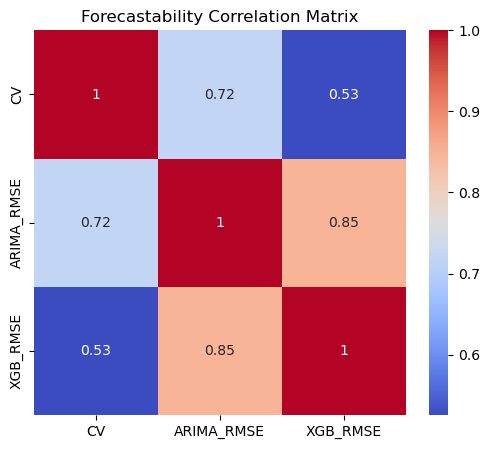

In [45]:
plt.figure(
    figsize=(6,5)
)

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title(
    "Forecastability Correlation Matrix"
)

plt.show()

## Main Figure

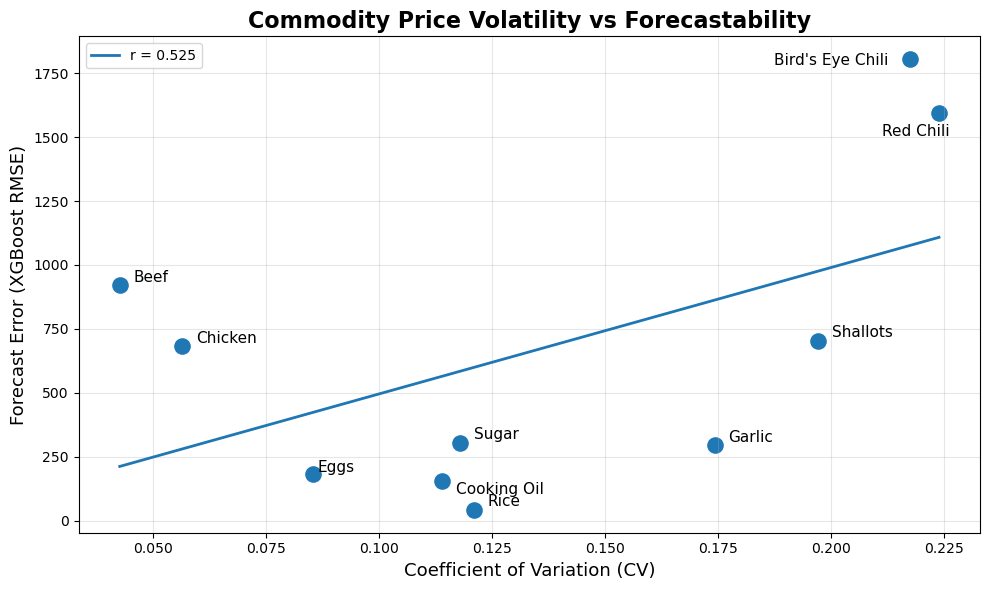

In [46]:
import matplotlib.pyplot as plt
from scipy.stats import linregress
import numpy as np

x = results["CV"]
y = results["XGB_RMSE"]

# Linear trend
slope, intercept, r, p, se = linregress(x, y)

plt.figure(figsize=(10, 6))

# Scatter
plt.scatter(
    x,
    y,
    s=120
)

# Regression line
x_line = np.linspace(x.min(), x.max(), 100)

plt.plot(
    x_line,
    intercept + slope * x_line,
    linewidth=2,
    label=f"r = {r:.3f}"
)

# Custom label positions
offsets = {
    "Red Chili": (-0.0125, -90),
    "Bird's Eye Chili": (-0.03, -25),
    "Shallots": (0.003, 15),
    "Garlic": (0.003, 10),
    "Rice": (0.003, 15),
    "Sugar": (0.003, 15),
    "Cooking Oil": (0.003, -50),
    "Egg": (0.003, 10),
    "Chicken": (0.003, 10),
    "Beef": (0.003, 10)
}

for _, row in results.iterrows():

    dx, dy = offsets.get(
        row["Commodity"],
        (0.001, 10)
    )

    plt.annotate(
        row["Commodity"],
        (
            row["CV"] + dx,
            row["XGB_RMSE"] + dy
        ),
        fontsize=11
    )

plt.xlabel(
    "Coefficient of Variation (CV)",
    fontsize=13
)

plt.ylabel(
    "Forecast Error (XGBoost RMSE)",
    fontsize=13
)

plt.title(
    "Commodity Price Volatility vs Forecastability",
    fontsize=16,
    fontweight="bold"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()